# 03 - Baseline Model
Simple Linear Regression baseline: earthquake magnitude → stock return.

## 1. Load Datasets

In [1]:
import pandas as pd

eq = pd.read_csv('../data/clean/earthquake_clean.csv')
stocks = pd.read_csv('../data/clean/stocks_clean.csv')

# Parse dates
eq['date'] = pd.to_datetime(eq['date'], format='ISO8601')
stocks['date'] = pd.to_datetime(stocks['date'], format='ISO8601')

# Remove timezone info from both
eq['date'] = eq['date'].dt.tz_localize(None)
stocks['date'] = stocks['date'].dt.tz_localize(None)

# Strip time from earthquake dates so both have date only
eq['date'] = eq['date'].dt.normalize()
stocks['date'] = stocks['date'].dt.normalize()

print("Earthquake dates sample:")
print(eq['date'].head())
print("\nStock dates sample:")
print(stocks['date'].head())

Earthquake dates sample:
0   2011-04-06
1   2011-04-07
2   2011-04-07
3   2011-04-09
4   2011-04-09
Name: date, dtype: datetime64[us]

Stock dates sample:
0          NaT
1   2010-01-04
2   2010-01-05
3   2010-01-06
4   2010-01-07
Name: date, dtype: datetime64[us]


## 2. Merge Datasets

In [2]:
df = pd.merge(eq, stocks, on='date', how='inner')
print('Merged shape:', df.shape)
df.head()

Merged shape: (917, 5)


,date,magnitude,place,close,return
0,2011-04-06,5.3,"42 km ENE of Namie, Japan",467.6549377441406,0.009726
1,2011-04-07,7.1,"29 km ESE of Ishinomaki, Japan",470.9309997558594,0.007005
2,2011-04-07,5.1,"88 km ESE of Yamada, Japan",470.9309997558594,0.007005
3,2011-04-11,6.6,"17 km SSW of Ishikawa, Japan",479.12109375,0.018277
4,2011-04-11,5.8,"14 km SSE of Marumori, Japan",479.12109375,0.018277


## 3. Prepare Features

In [3]:
X = df[['magnitude']]
y = df['return']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (917, 1)
y shape: (917,)


## 4. Train Baseline Model (Linear Regression)

In [4]:
print("Earthquake dates sample:")
print(eq['date'].head())
print("\nStock dates sample:")
print(stocks['date'].head())

Earthquake dates sample:
0   2011-04-06
1   2011-04-07
2   2011-04-07
3   2011-04-09
4   2011-04-09
Name: date, dtype: datetime64[us]

Stock dates sample:
0          NaT
1   2010-01-04
2   2010-01-05
3   2010-01-06
4   2010-01-07
Name: date, dtype: datetime64[us]


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained!')
print('Coefficient:', model.coef_[0])
print('Intercept:', model.intercept_)

Model trained!
Coefficient: 0.002697098448209353
Intercept: -0.012571495484763502


## 5. Make Predictions

In [6]:
predictions = model.predict(X_test)
print('Predictions done. Sample:', predictions[:5])

Predictions done. Sample: [0.00199284 0.00415051 0.000914   0.00172313 0.000914  ]


## 6. Evaluate

In [7]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print('MSE:', mse)
print('R² Score:', r2)

MSE: 0.0003735385836062164
R² Score: -0.006549873082050572


## 7. Plot Results

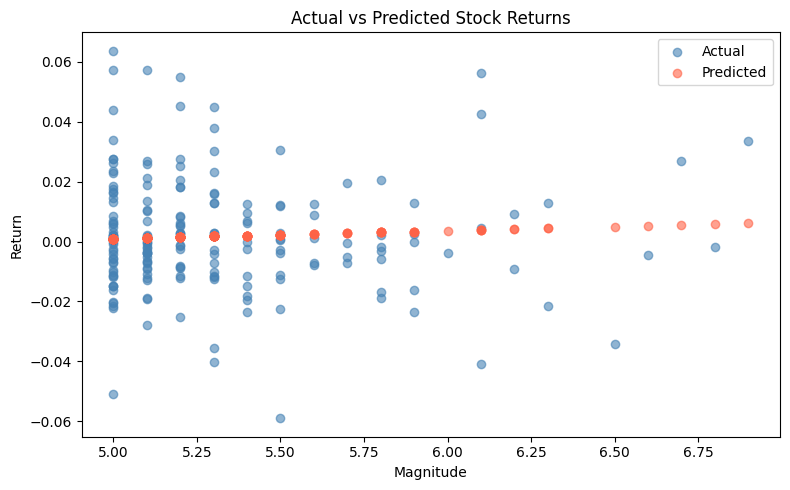

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, label='Actual', alpha=0.6, color='steelblue')
plt.scatter(X_test, predictions, label='Predicted', alpha=0.6, color='tomato')
plt.xlabel('Magnitude')
plt.ylabel('Return')
plt.title('Actual vs Predicted Stock Returns')
plt.legend()
plt.tight_layout()
plt.show()

## ✅ Baseline done. Next step: LSTM model.